## Week7 - Part1: Transfer Learning with Pre-trained Models

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. 

In this notebook, we will demonstrate how to apply transfer learning on pre trained models. In the first part, we define and train a simple CNN model from scratch on a MNIST dataset and use transfer learning to transfer knowledge from a pre-trained model to our unseen classes. In the second part, we will use keras application and fine-tune a pre-trained model on a MNIST dataset.

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping
from IPython.display import clear_output
import matplotlib.pyplot as plt

import os

In [3]:
class LossPlotter(Callback):
    def on_train_begin(self, logs={}):
        self.i= 0
        self.x= []
        self.losses = []
        self.val_losses = []
        self.fig = plt.figure()
        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        loss = logs.get('loss')
        self.losses.append(loss)
        self.val_losses.append(logs.get('val_loss'))
        self.i += 1

        clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.plot(self.x, self.losses, label="Loss")
        plt.plot(self.x, self.val_losses, label="Validation Loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Over Epochs')
        plt.legend()
        plt.grid('on')
        plt.show()

## Loading MNIST Dataset

We use the MNIST dataset, which consists of 70,000 images of handwritten digits (0-9) in grayscale. The dataset is divided into a training set of 60,000 images and a test set of 10,000 images. Each image is 28x28 pixels in size.
The dataset is available in the `keras.datasets` module, and we can load it using the following code:

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.expand_dims(x_train.astype("float32") / 255.0, -1)
x_test = np.expand_dims(x_test.astype("float32") / 255.0, -1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


# Part 1: Transfer Learning with Custom Pre-trained Models

In this part, we will define a simple CNN model and train it on the MNIST dataset. We train a base model to learn first 6 classes (0-5) and then we will use transfer learning to transfer knowledge from the base model to a new model that learns the remaining 4 classes (6-9).

The base model is used for feature extraction, and the new model is trained on the features extracted from the base model

In [ ]:
x_train_low = x_train[y_train < 6]
y_train_low = y_train[y_train < 6]
x_test_low = x_test[y_test < 6]
y_test_low = y_test[y_test < 6]

x_train_high = x_train[y_train >= 6]
y_train_high = y_train[y_train >= 6]
x_test_high = x_test[y_test >= 6]
y_test_high = y_test[y_test >= 6]

# Encoding the labels
y_train_low_cat = to_categorical(y_train_low, 6)
y_test_low_cat = to_categorical(y_test_low, 6)
y_train_high_cat = to_categorical(y_train_high - 6, 4)
y_test_high_cat = to_categorical(y_test_high - 6, 4)

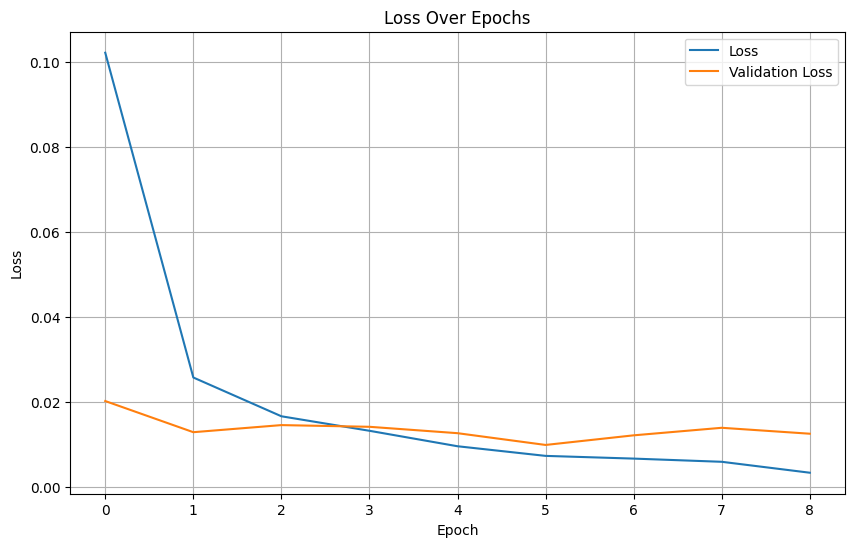

1126/1126 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9970 - val_loss: 0.0125
Epoch 9: early stopping


In [ ]:
base_model = Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

earlystopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
History_base = base_model.fit(x_train_low, y_train_low_cat, epochs=100, validation_data=(x_test_low, y_test_low_cat), callbacks=[earlystopping, LossPlotter()])

## Strategy 1: Pre-train base model last layers
We will freeze all layers except the last two layer of the base model. The last layers will be trained on the new dataset.

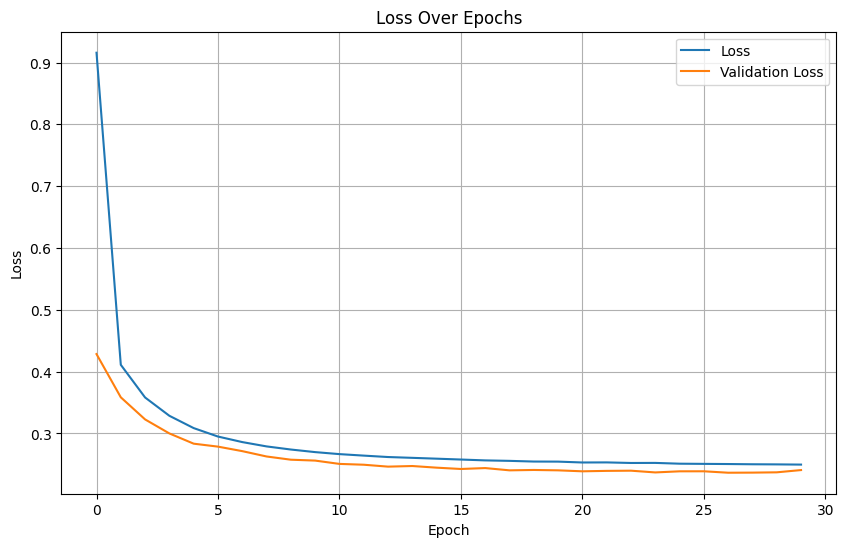

750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9135 - loss: 0.2489 - val_accuracy: 0.9146 - val_loss: 0.2407
Epoch 30: early stopping
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9047 - loss: 0.2647
Transfer Model Strategy 1 Accuracy: 0.9146


In [ ]:
model_base_clone = keras.models.clone_model(base_model)
model_base_clone.set_weights(base_model.get_weights())

model_1_TL = keras.models.Sequential(model_base_clone.layers[:-1])
model_1_TL.add(keras.layers.Dense(4, activation="sigmoid"))

# Freeze all base layers
for layer in model_1_TL.layers[:-2]:
    layer.trainable = False

model_1_TL.compile(loss="categorical_crossentropy",
               optimizer=keras.optimizers.Adam(learning_rate=1e-3),
               metrics=["accuracy"])

earlystopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
History_1_TL = model_1_TL.fit(x_train_high, y_train_high_cat, epochs=50, validation_data=(x_test_high, y_test_high_cat), callbacks=[earlystopping, LossPlotter()])

# Evaluate transfer model 1
model1_loss, model1_acc = model_1_TL.evaluate(x_test_high, y_test_high_cat)
print(f"Transfer Model Strategy #1 Accuracy: {model1_acc:.4f}")

## Strategy 2: Freeze base model and add new layers
In the second strategy, we will freeze the base model and add new layers on top of it. The new layers will be trained on the new dataset. This strategy is useful when the base model is already well-trained and we want to fine-tune it for a specific task.

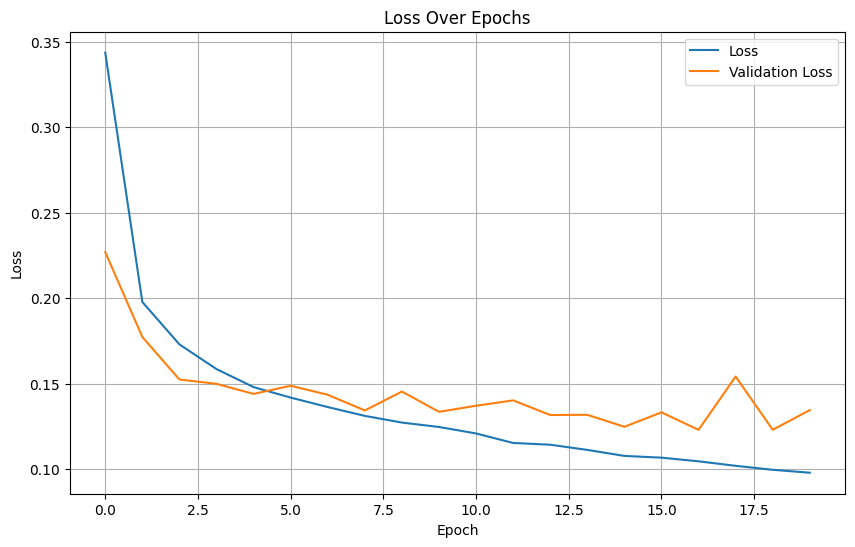

750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9668 - loss: 0.0983 - val_accuracy: 0.9541 - val_loss: 0.1346
Epoch 20: early stopping
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9519 - loss: 0.1461
Transfer Model Strategy #2 Accuracy: 0.9541


In [ ]:
model_2_TL = keras.models.Sequential(model_base_clone.layers[:-1])
model_2_TL.add(keras.layers.Dense(64, activation='relu'))
model_2_TL.add(keras.layers.Dense(32, activation='relu'))
model_2_TL.add(keras.layers.Dense(4, activation='softmax'))

# Freeze all base layers
for layer in model_2_TL.layers[:-3]:
    layer.trainable = False

model_2_TL.compile(loss="categorical_crossentropy",
               optimizer=keras.optimizers.Adam(learning_rate=1e-3),
               metrics=["accuracy"])

earlystopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
History_2_TL = model_2_TL.fit(x_train_high, y_train_high_cat, epochs=50, validation_data=(x_test_high, y_test_high_cat), callbacks=[earlystopping, LossPlotter()])

# Evaluate transfer model 1
model2_loss, model2_acc = model_2_TL.evaluate(x_test_high, y_test_high_cat)
print(f"Transfer Model Strategy #2 Accuracy: {model2_acc:.4f}")

## Part 2:  Uning Keras Applications
Keras provides a number of pre-trained models that can be used for transfer learning. These models are trained on large datasets such as ImageNet, ResNet, MobileNetV2, EfficientNet, etc. These models can be fine-tuned for our specific tasks.

In this part we will use CIFAR10 dataset and EfficientNetB0 model to classify the images.

In [20]:
# Load CIFAR-10 and get a subset of the data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

num_train_samples = 1000
indices = np.random.permutation(len(x_train))[:num_train_samples]
x_train = x_train[indices]
y_train = y_train[indices]


num_test_samples = 100
indices = np.random.permutation(len(x_test))[:num_test_samples]
x_test = x_test[indices]
y_test = y_test[indices]

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Resize images to match EfficientNet input
x_train_resized = tf.image.resize(x_train, (224, 224))
x_test_resized = tf.image.resize(x_test, (224, 224))

## Build and Compile the Model
We add new layers on top of the pre-trained base model.

In [31]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])


## Compile and Train the Model
We freeze the base model except the some last layers and train the model on the CIFAR10 dataset.

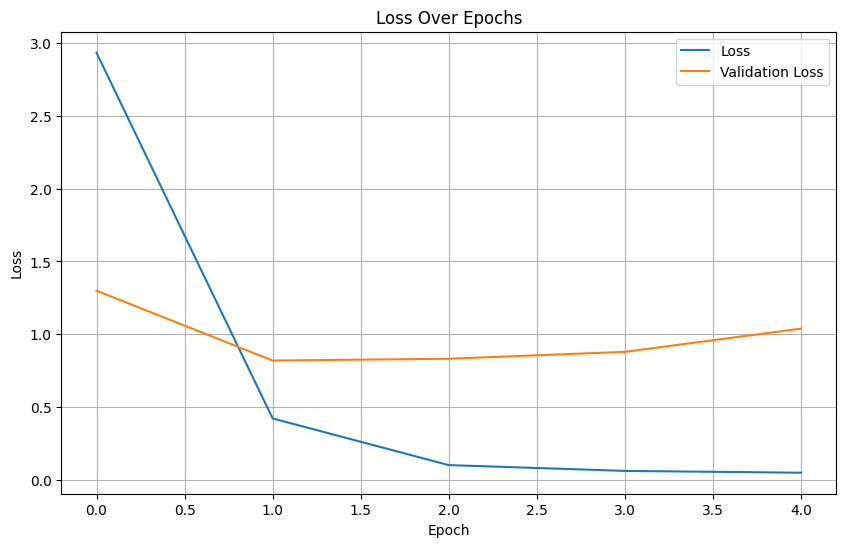

32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 455ms/step - accuracy: 0.9844 - loss: 0.0479 - val_accuracy: 0.7500 - val_loss: 1.0394
Epoch 5: early stopping


In [32]:
for layer in model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
earlystopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)
History = model.fit(x_train_resized, y_train_cat, epochs=5, validation_data=(x_test_resized, y_test_cat), callbacks=[earlystopping, LossPlotter()])